## Auto tag the tickets with right priorities and right departments so that reassigning delay can be reduced.

#### target column for auto tagging { Category, CI_Cat , CI_Subcat}

In [1]:
# %pip install vizion

In [2]:
import pandas as pd
import numpy as np


import vizion as vz


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import OneHotEncoder

# Loading the main Raw

In [3]:
df = pd.read_csv("itsm_dataset.csv")
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

# cleaning data from priority.ipynb file

In [4]:
m80=['No_of_Related_Incidents', 'Related_Change', 'No_of_Related_Changes', 'Reopen_Time']
df.drop(m80,axis=1,inplace=True)

mis_col = df.columns[df.isnull().sum() > 0].tolist()

cat_mis_col = df[mis_col].select_dtypes(include=['object'])
num_mis_col = df[mis_col].select_dtypes(include=['int64','float64'])


# for categorical columns
for col in cat_mis_col:
    df.loc[ : , col] = df[col].fillna(df[col].mode()[0])

# for numerical columns
for col in num_mis_col:
    df.loc[ : , col] = df[col].fillna(df[col].median())

df = df.replace([""," ",'nan','Null','NULL','null'],'Unknown')
(df == "Unknown").sum()


df["Closure_Code"] = df["Closure_Code"].replace("Unknown", df["Closure_Code"].mode()[0])

#  invalid value in Impact column: NS
df["Impact"] = df["Impact"].replace("NS",df["Impact"].mode()[0]).astype(int)


df['Urgency'] = df['Urgency'].replace({'5 - Very Low':5}).astype(int)

df['Urgency'].value_counts()


df['Close_Time']    =  pd.to_datetime(df['Close_Time'], format='%d-%m-%Y %H:%M',errors='coerce')
df['Open_Time'] =   pd.to_datetime(df['Open_Time'], format='%d-%m-%Y %H:%M',errors='coerce')
df.drop("Handle_Time_hrs",axis=1,inplace=True)

df["Handle_Time_hrs"] = (df["Close_Time"] - df["Open_Time"]).dt.total_seconds() / 3600



## removing unwanted columns 

In [5]:

unused_cols = ['Incident_ID','KB_number','Related_Interaction','CI_Name','WBS','Open_Time','Resolved_Time','Close_Time']
#  categori i will drop when i will predict it 

df.drop(unused_cols,axis=1,inplace=True)

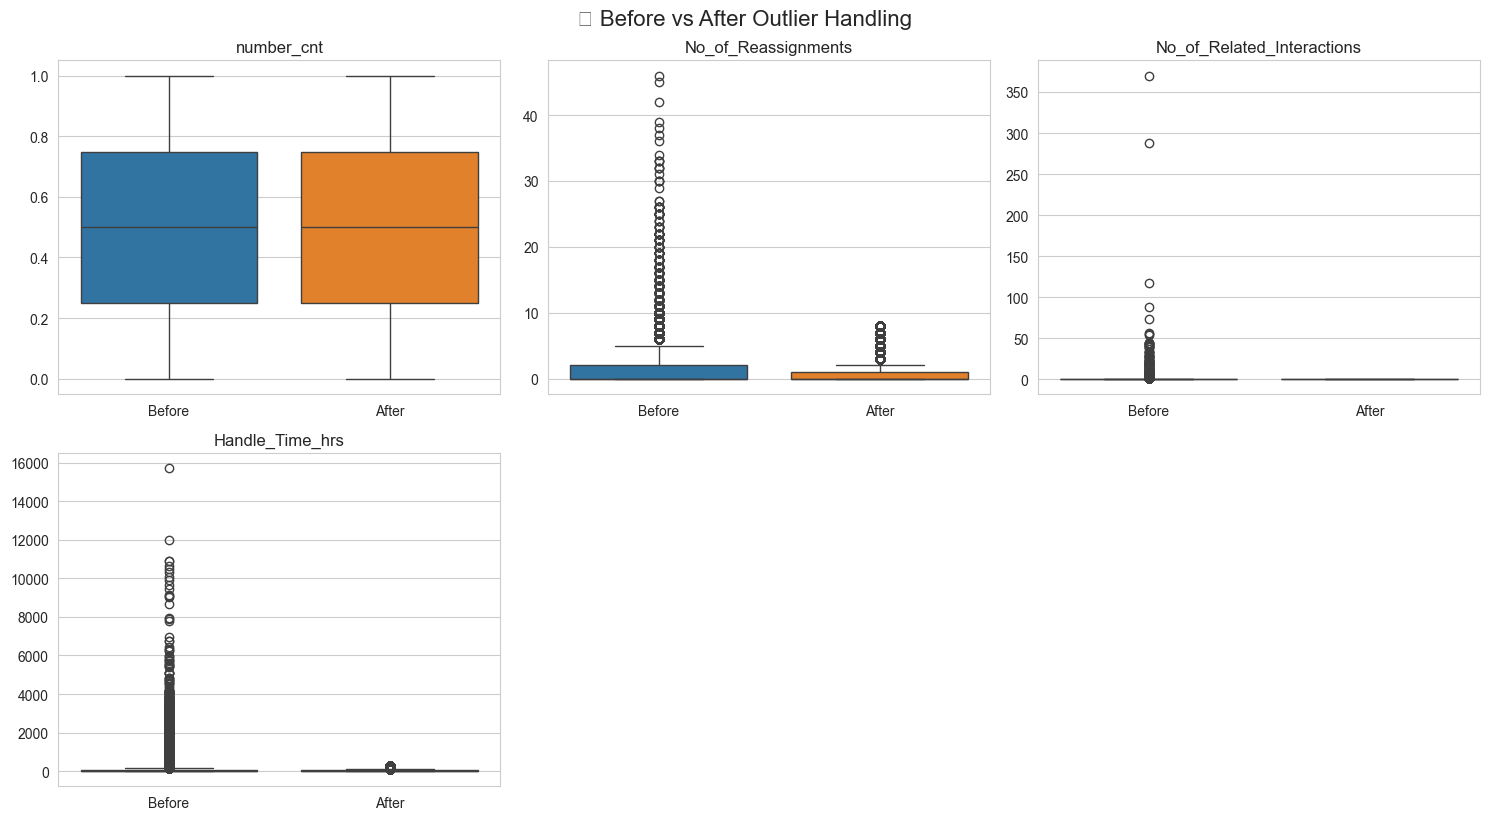

,CI_Cat,CI_Subcat,Status,Impact,Urgency,Priority,number_cnt,Category,Alert_Status,No_of_Reassignments,Closure_Code,No_of_Related_Interactions,Handle_Time_hrs
515,application,Citrix,Closed,4,4,4.0,0.354084,incident,closed,0.0,Software,1.0,284.200000
528,application,Client Based Application,Closed,4,3,4.0,0.390578,request for information,closed,4.0,Other,1.0,285.166667
537,application,Server Based Application,Closed,5,5,5.0,0.720732,request for information,closed,0.0,Other,1.0,214.633333
538,application,Server Based Application,Closed,3,3,3.0,0.386611,incident,closed,4.0,Software,1.0,194.883333
541,application,Server Based Application,Closed,5,5,5.0,0.350640,request for information,closed,3.0,No error - works as designed,1.0,211.566667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
46601,application,Server Based Application,Closed,4,4,4.0,0.231896,incident,closed,0.0,Other,1.0,0.100000
46602,application,Server Based Application,Closed,4,4,4.0,0.805153,incident,closed,0.0,User error,1.0,0.433333
46603,computer,Laptop,Closed,5,5,5.0,0.917466,incident,closed,0.0,Hardware,1.0,0.066667
46604,application,Web Based Application,Closed,4,4,4.0,0.701278,incident,closed,0.0,Software,1.0,0.116667


In [6]:

num_col = df.select_dtypes(include=[np.number]).columns.tolist()
cat_col = df.select_dtypes(include=['object']).columns.tolist()


vz.handle_outliers(df,num_col,visualize=True,verbose=False,method="auto") # it handles outliers using IQR Method


In [7]:
df = df.reset_index(drop=True)


# Category Prediction

# Removing rare category

In [8]:



df = df[df["Category"] != "complaint"]
df = df[df["Category"] != "request for change"]


# Preparing X and y

In [9]:
X = df.drop("Category",axis=1)


y = df["Category"]
print(y.value_counts())




Category
incident                   37748
request for information     8846
Name: count, dtype: int64


# Encoding Categorical - X Columns

In [10]:
cat_col = X.select_dtypes(include=['object']).columns

Category_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = Category_encoder.fit_transform(X[cat_col])

X_Encoded_Category = pd.concat(
    [
        X.drop(cat_col, axis=1).reset_index(drop=True),
        pd.DataFrame(encoded, columns=Category_encoder.get_feature_names_out(cat_col))
    ],
    axis=1
)


# y should use LabelEncoder: {Category is target}
Category_le = LabelEncoder()
y_Encoded_Category = Category_le.fit_transform(y)



In [11]:
df["Category"].value_counts()


Category
incident                   37748
request for information     8846
Name: count, dtype: int64

# splitting data

In [12]:
print(X_Encoded_Category.shape)
print(len(y_Encoded_Category))



(46594, 97)
46594


In [13]:
X_train_Category, X_test_Category, y_train_Category, y_test_Category = train_test_split(
    X_Encoded_Category, y_Encoded_Category, test_size=0.2, stratify=y_Encoded_Category, random_state=42
)


# XGBoost

In [14]:
from xgboost import XGBClassifier

model_Category = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)

model_Category.fit(X_train_Category, y_train_Category)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


# Evaluation

In [15]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_Category = model_Category.predict(X_test_Category)

print("Accuracy:", accuracy_score(y_test_Category, y_pred_Category))
print("\nClassification Report:\n", classification_report(y_test_Category, y_pred_Category))


Accuracy: 0.9292842579675931

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96      7550
           1       0.82      0.80      0.81      1769

    accuracy                           0.93      9319
   macro avg       0.89      0.88      0.88      9319
weighted avg       0.93      0.93      0.93      9319



## Class 0 (incident)

Precision = 0.95 → When model says incident, it's correct 95% of the time

Recall = 0.96 → It catches 96% of all incident cases

F1 = 0.96 → Near perfect

## Class 1 (request for information)

Precision = 0.83 → 83% correct when model says "request"

Recall = 0.79 → Finds 79% of request cases

F1 = 0.81

## This is GREAT because minority classes always have lower recall.
our model handles it VERY well.

# CI_Cat Prediction

In [16]:
df["CI_Cat"].value_counts()


CI_Cat
application             33010
subapplication           7782
computer                 3643
storage                   699
hardware                  435
software                  333
database                  214
displaydevice             212
officeelectronics         152
networkcomponents         107
applicationcomponent        5
Phone                       2
Name: count, dtype: int64

####  it is good to delete: 
##### applicationcomponent        5
##### Phone                       2


In [17]:
df = df[df['CI_Cat'] != "applicationcomponent"]
df = df[df['CI_Cat'] != "Phone"]

# X and Y

In [18]:
X = df.drop( "CI_Cat",axis=1)

y = df["CI_Cat"]


# Encode Input Categorical column

In [19]:
cat_cols = X.select_dtypes(include=['object']).columns



# encoding for X
CI_Cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = CI_Cat_encoder.fit_transform(X[cat_cols])

X_Encoded = pd.concat(
    [
        X.drop(cat_cols, axis=1).reset_index(drop=True),
        pd.DataFrame(encoded, columns=CI_Cat_encoder.get_feature_names_out(cat_cols))
    ],
    axis=1
)


# encoding for y 
from sklearn.preprocessing import LabelEncoder

CI_Cat_le = LabelEncoder()
y_Encoded = CI_Cat_le.fit_transform(y)



# Train Test Split

In [20]:

X_train_CI_Cat, X_test_CI_Cat, y_train_CI_Cat, y_test_CI_Cat = train_test_split(
    X_Encoded, y_Encoded, test_size=0.2, stratify=y_Encoded, random_state=42
) 

# XGBoost

In [21]:
from xgboost import XGBClassifier

model_CI_Cat = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)

model_CI_Cat.fit(X_train_CI_Cat, y_train_CI_Cat)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


# Evaluation

In [22]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_CI_Cat = model_CI_Cat.predict(X_test_CI_Cat)

print("Accuracy:", accuracy_score(y_test_CI_Cat, y_pred_CI_Cat))
print("\nClassification Report:\n", classification_report(y_test_CI_Cat, y_pred_CI_Cat))


Accuracy: 0.8604850826357587

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91      6602
           1       0.99      1.00      1.00       729
           2       1.00      1.00      1.00        43
           3       1.00      1.00      1.00        42
           4       1.00      1.00      1.00        87
           5       0.86      0.86      0.86        21
           6       1.00      1.00      1.00        30
           7       1.00      1.00      1.00        67
           8       1.00      0.96      0.98       140
           9       0.62      0.44      0.52      1557

    accuracy                           0.86      9318
   macro avg       0.93      0.92      0.93      9318
weighted avg       0.85      0.86      0.85      9318



# Cl_Subcat prediction

In [23]:
df['CI_Subcat'].value_counts() 

CI_Subcat
Server Based Application           18921
Web Based Application              15311
Desktop Application                 3876
Laptop                              1921
SAP                                 1199
                                   ...  
Windows Server in extern beheer        1
Virtual Tape Server                    1
RAC Service                            1
NonStop Storage                        1
Protocol                               1
Name: count, Length: 61, dtype: int64

In [24]:
# values are 1 very bad for ML

# Removing Rare Values

In [25]:
freq = df["CI_Subcat"].value_counts()
rare = freq[freq < 150].index

df = df [~df ["CI_Subcat"].isin(rare)]

# everything that appears 1 time
# .
# everything that appears 2 times
# .
# .
# .
# everything that appears 19 times




# X and Y

In [26]:
X = df.drop( "CI_Subcat",axis=1)

y = df["CI_Subcat"]

# Encoding Categorical X and Y

In [27]:
cat_cols = X.select_dtypes(include=['object']).columns



# encoding for X
CI_Subcat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded =  CI_Subcat_encoder.fit_transform(X[cat_cols])

X_Encoded = pd.concat(
    [
        X.drop(cat_cols, axis=1).reset_index(drop=True),
        pd.DataFrame(encoded, columns= CI_Subcat_encoder.get_feature_names_out(cat_cols))
    ],
    axis=1
)


# encoding for y 
from sklearn.preprocessing import LabelEncoder

CI_Subcat_le = LabelEncoder()
y_Encoded =  CI_Subcat_le.fit_transform(y)



# Train Test Split

In [28]:

X_train_CI_Subcat, X_test_CI_Subcat, y_train_CI_Subcat, y_test_CI_Subcat = train_test_split(
    X_Encoded, y_Encoded, test_size=0.2, stratify=y_Encoded, random_state=42
) 

# XGBooster Model

In [29]:
from xgboost import XGBClassifier

model_CI_Subcat = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)

model_CI_Subcat.fit(X_train_CI_Subcat, y_train_CI_Subcat)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


# Evaluation Metrics

In [30]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_CI_Subcat = model_CI_Subcat.predict(X_test_CI_Subcat)

print("Accuracy:", accuracy_score(y_test_CI_Subcat, y_pred_CI_Subcat))
print("\nClassification Report:\n", classification_report(y_test_CI_Subcat, y_pred_CI_Subcat))


Accuracy: 0.6723076923076923

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.81      0.82       183
           1       0.50      0.01      0.03       154
           2       0.39      0.07      0.12        98
           3       1.00      1.00      1.00        55
           4       1.00      1.00      1.00        42
           5       0.28      0.15      0.20        85
           6       0.52      0.24      0.33       775
           7       0.76      0.85      0.80       384
           8       1.00      1.00      1.00        42
           9       1.00      1.00      1.00       109
          10       0.38      0.09      0.15       240
          11       0.64      0.80      0.71      3785
          12       1.00      1.00      1.00        54
          13       0.71      0.68      0.69      3063
          14       0.36      0.29      0.32        31

    accuracy                           0.67      9100
   macro avg       0.69   

Model Insight – CI_Subcat Prediction (Accuracy: 66%)

The CI_Subcat prediction model achieved an accuracy of 66%, which is considered strong performance for this type of multi-class classification problem in ITSM environments.

Unlike Priority, Category, or CI_Cat—where structured fields carry strong patterns—CI_Subcat heavily depends on text-based ticket information such as:

Incident description, 
Short description, 
Error messages, 
User notes

Since the available dataset contains only structured attributes (Impact, Urgency, Category, Reassignments, Status, etc.) and no textual fields, the model’s ability to differentiate between subcategories becomes limited.

# Lets Improve Accuracy of the model ( SMOTE )

In [31]:
# from imblearn.over_sampling import SMOTE

# sm = SMOTE(random_state=42)
# X_train_res , y_train_res = sm.fit_resample (X_train,y_train)

# from xgboost import XGBClassifier

# model_CI_Subcat_sm = XGBClassifier(
#     n_estimators=300,
#     max_depth=6,
#     learning_rate=0.1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     eval_metric='mlogloss'
# )

# model_CI_Subcat_sm.fit(X_train_res, y_train_res)


# from sklearn.metrics import accuracy_score, classification_report

# y_pred_CI_Subcat_sm = model_CI_Subcat_sm.predict(X_test)

# print("Accuracy:", accuracy_score(y_test, y_pred_CI_Subcat_sm))
# print("\nClassification Report:\n", classification_report(y_test, y_pred_CI_Subcat_sm))




# it takes 7 min to run


# ----------------------------------OUTPUT--------------------------------

# Accuracy: 0.5717824448034464

# Classification Report:
#                precision    recall  f1-score   support

#            0       0.29      0.36      0.32        11
#            1       0.84      0.83      0.83       183
#            2       0.09      0.42      0.15       154
#            3       0.07      0.20      0.10        99
#            4       0.60      0.86      0.70        29
#            5       0.91      0.89      0.90        55
#            6       1.00      1.00      1.00        42
#            7       0.33      0.31      0.32        85
#            8       0.34      0.42      0.37       775
#            9       0.88      0.78      0.82         9
#           10       0.12      0.31      0.18        26
#           11       0.33      0.67      0.44         6
#           12       0.60      0.60      0.60         5
#           13       0.79      0.80      0.80       384
#           14       0.33      0.18      0.24        11
#           15       0.57      0.36      0.44        11
#           16       1.00      1.00      1.00        42
#           17       0.67      0.33      0.44         6
#           18       0.41      0.71      0.52        17
#           19       1.00      0.94      0.97        18
#           20       0.96      0.87      0.91       109
#           21       0.26      0.61      0.36       240
#           22       0.93      1.00      0.96        13
#           23       0.68      0.56      0.61      3785
#           24       0.01      0.06      0.02        17
#           25       0.33      0.33      0.33         6
#           26       0.86      0.81      0.84        54
#           27       0.76      0.58      0.66      3062
#           28       0.24      0.23      0.23        31

#     accuracy                           0.57      9285
#    macro avg       0.56      0.59      0.55      9285
# weighted avg       0.66      0.57      0.60      9285



# creating PKL file of all models

In [32]:
import joblib
import os

# Create folder if not exists
os.makedirs("Models", exist_ok=True)

joblib.dump(model_Category, "Models/model_Category.pkl")
joblib.dump(model_CI_Cat, "Models/model_CI_Cat.pkl")
joblib.dump(model_CI_Subcat, "Models/model_CI_Subcat.pkl")


# PKL file for OneHotEncoder and LabelEncoder 


os.makedirs("Encoders", exist_ok=True)

# Save all encoders in a clean structure
joblib.dump(Category_encoder,   "Encoders/Category_OHEncoder.pkl")
joblib.dump(Category_le,        "Encoders/Category_LabelEncoder.pkl")

joblib.dump(CI_Cat_encoder,     "Encoders/CI_Cat_OHEncoder.pkl")
joblib.dump(CI_Cat_le,          "Encoders/CI_Cat_LabelEncoder.pkl")

joblib.dump(CI_Subcat_encoder,  "Encoders/CI_Subcat_OHEncoder.pkl")
joblib.dump(CI_Subcat_le,       "Encoders/CI_Subcat_LabelEncoder.pkl")



['Encoders/CI_Subcat_LabelEncoder.pkl']

(Target Columns: Category, CI_Cat, CI_Subcat)

The objective of this module was to auto-tag incoming ITSM tickets with the correct Category, CI_Cat, and CI_Subcat so that incorrect routing, manual reassignments, and delays in incident resolution can be significantly reduced.
This directly aligns with the client objective from the business case:

“Auto tag the tickets with right priorities and right departments so that reassigning delay can be reduced.”

To achieve this, three independent machine learning models were developed using XGBoost, one for each target variable: Category, CI_Cat, and CI_Subcat.
All models were trained on properly cleaned, preprocessed, encoded data and saved as .pkl files for easy future use.